In [37]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import plotly.graph_objects as go

In [38]:
ticker_symbols = ["^GSPC", "^NDX", "QQQ", "AAPL", "NVDA", "AMZN"]

In [39]:
end_date = datetime.datetime.today()

start_date = end_date - datetime.timedelta(days=2*365)

In [40]:
close_df = pd.DataFrame()

for ticker in ticker_symbols:
    data = yf.download(ticker, start=start_date, end=end_date)
    close_df[ticker] = data["Close"]

print(close_df)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

                  ^GSPC          ^NDX         QQQ        AAPL        NVDA  \
Date                                                                        
2024-06-10  5360.790039  19074.669922  459.780457  191.461487  121.579613   
2024-06-11  5375.319824  19210.179688  462.935822  205.370972  120.711052   
2024-06-12  5421.029785  19465.179688  468.999268  211.240143  124.993988   
2024-06-13  5433.740234  19576.919922  471.541351  212.400101  129.396744   
2024-06-14  5431.600098  19659.800781  473.984467  210.665115  131.663010   
...                 ...           ...         ...         ...         ...   
2026-06-04  7584.310059  30407.810547  740.609985  311.230011  218.660004   
2026-06-05  7383.740234  28957.599609  705.059998  307.339996  205.100006   
2026-06-08  7405.729980  29414.259766  716.070007  301.540009  208.639999   
2026-06-09  7386.649902  29084.500000  707.830017  290.549988  208.190002   
2026-06-10  7317.120117  28689.906250  698.570007  292.399994  203.139999   

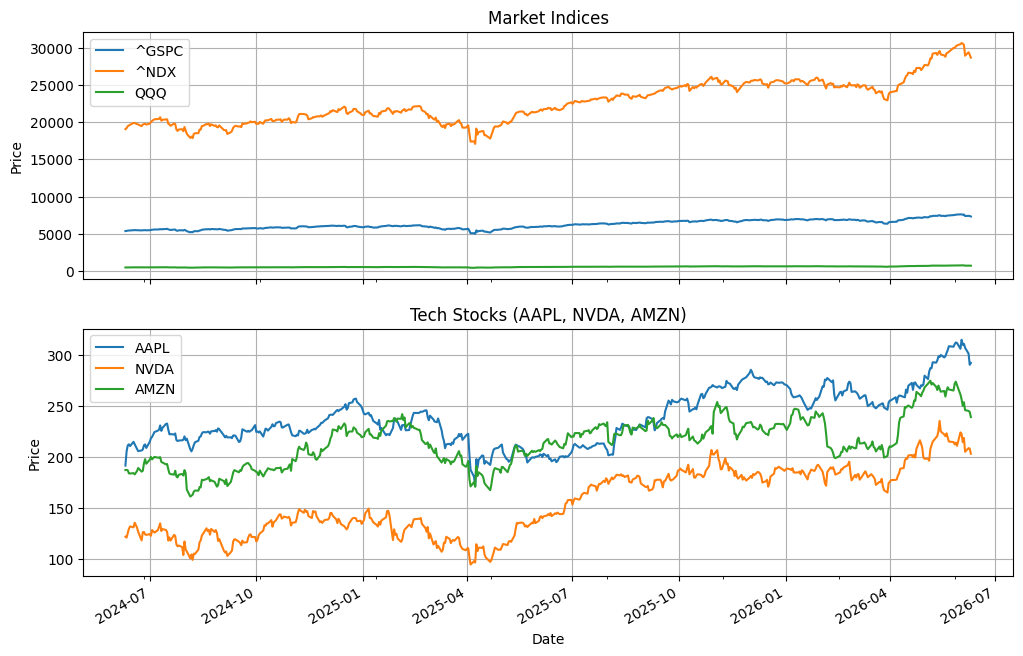

In [41]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)

indices = ["^GSPC", "^NDX", "QQQ"]
close_df[indices].plot(ax=ax1)
ax1.set_title("Market Indices")
ax1.set_ylabel("Price")
ax1.grid(True)
ax1.legend(loc="upper left")

stocks = ["AAPL", "NVDA", "AMZN"]
close_df[stocks].plot(ax=ax2)
ax2.set_title("Tech Stocks (AAPL, NVDA, AMZN)")
ax2.set_ylabel("Price")
ax2.grid(True)
ax2.legend(loc='upper left')

plt.show()

In [42]:
def plot_candlestick(data, ticker):
    # Flatten MultiIndex columns if yfinance returned them (common in v0.2+)
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
        
    fig = go.Figure(data=[go.Candlestick(x=data.index,
                                         open=data["Open"],
                                         high=data["High"],
                                         low=data["Low"],
                                         close=data["Close"])])
    
    fig.update_layout(
        title=f"{ticker} Candlestick Chart",
        yaxis_title="Price",
        xaxis_title="Date",
        xaxis_rangeslider_visible=True
    )
    
    return fig

end_date = datetime.datetime.today()
start_date = end_date - datetime.timedelta(days=365)

df = yf.download("NVDA", start=start_date, end=end_date)

fig = plot_candlestick(df, "NVDA")
fig.show()

[*********************100%***********************]  1 of 1 completed
